In [1]:
"""
=================================================
Physics-informed fit: Burgers' equation
=================================================

The canonical PINN benchmark (Raissi, Perdikaris & Karniadakis 2019, Fig. 1):
viscous Burgers' equation

  ``u_t + u u_x = ν u_xx`` on ``x ∈ [-1, 1], t ∈ [0, 1]``,
  ``u(x, 0) = -sin πx``, ``u(±1, t) = 0``.

It is nonlinear -- the residual contains ``u u_x`` -- and it steepens an
initially smooth profile into a front, so it exercises the whole derivative
API: ``u``, ``u_x``, ``u_xx`` from one ``order-2`` pass along ``(1, 0)``,
``u_t`` from an ``order-1`` pass along ``(0, 1)``, and a gradient of the
residual loss whose sensitivities to ``u`` (through ``u u_x``), to ``u_x``, to
``u_xx`` and to ``u_t`` all go back through ``backward_derivatives``.

The exact solution is the Cole-Hopf integral, evaluated here by Gauss-Hermite
quadrature -- the same reference Raissi's repository uses -- so the fit is
scored against the truth, not against another network.

Raissi's setting is ``ν = 0.01/π`` with a 2-20×8-1 network, 10 000 collocation
points and L-BFGS run to convergence (tens of thousands of iterations); the
front at that viscosity is a few grid cells wide. This example is sized to run
in about a minute in pure NumPy + tttrlib: ``ν = 0.05``, a 2-20-20-20-1 network,
2000 collocation points, 2000 iterations. The front is still there, just
resolvable. Change ``nu`` and the widths to reproduce the paper's case; the
code does not change.
"""

"\n=================================================\nPhysics-informed fit: Burgers' equation\n=================================================\n\nThe canonical PINN benchmark (Raissi, Perdikaris & Karniadakis 2019, Fig. 1):\nviscous Burgers' equation\n\n  ``u_t + u u_x = ν u_xx`` on ``x ∈ [-1, 1], t ∈ [0, 1]``,\n  ``u(x, 0) = -sin πx``, ``u(±1, t) = 0``.\n\nIt is nonlinear -- the residual contains ``u u_x`` -- and it steepens an\ninitially smooth profile into a front, so it exercises the whole derivative\nAPI: ``u``, ``u_x``, ``u_xx`` from one ``order-2`` pass along ``(1, 0)``,\n``u_t`` from an ``order-1`` pass along ``(0, 1)``, and a gradient of the\nresidual loss whose sensitivities to ``u`` (through ``u u_x``), to ``u_x``, to\n``u_xx`` and to ``u_t`` all go back through ``backward_derivatives``.\n\nThe exact solution is the Cole-Hopf integral, evaluated here by Gauss-Hermite\nquadrature -- the same reference Raissi's repository uses -- so the fit is\nscored against the truth, not 

In [2]:
import json
import time

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss
from scipy.optimize import minimize

import tttrlib

rng = np.random.default_rng(2)
nu = 0.05


def make_net(dims, activation="tanh", seed=0):
    """An untrained network of the given widths, Glorot-initialised, no scalers."""
    r = np.random.default_rng(seed)
    layers = []
    for i in range(len(dims) - 1):
        n_in, n_out = dims[i], dims[i + 1]
        w = r.normal(size=(n_out, n_in)) * np.sqrt(2.0 / (n_in + n_out))
        layers.append({"n_in": n_in, "n_out": n_out,
                       "activation": activation if i < len(dims) - 2 else "identity",
                       "weight": w.ravel().tolist(), "bias": [0.0] * n_out})
    return tttrlib.NeuralNet.from_json_string(json.dumps(
        {"format": "tttrlib.neural_net", "version": 1, "layers": layers}))


def burgers_exact(x, t, nu, n_nodes=200):
    """Cole-Hopf solution for ``u(x, 0) = -sin πx`` by Gauss-Hermite quadrature.

    ``u = ∫ (x-y)/t · e^{-G} dy / ∫ e^{-G} dy`` with
    ``G = (x-y)²/(4νt) + (cos πy - 1)/(2πν)``; the substitution
    ``y = x - √(4νt) η`` turns the Gaussian factor into the Hermite weight.
    """
    eta, w = hermgauss(n_nodes)
    x, t = np.broadcast_arrays(np.asarray(x, float), np.asarray(t, float))
    u = np.empty(x.shape)
    for idx in np.ndindex(x.shape):
        xi, ti = x[idx], t[idx]
        if ti <= 0:
            u[idx] = -np.sin(np.pi * xi)
            continue
        y = xi - np.sqrt(4 * nu * ti) * eta
        F = (np.cos(np.pi * y) - 1.0) / (2 * np.pi * nu)
        e = np.exp(-F - (-F).max())
        u[idx] = np.sum(w * e * (xi - y) / ti) / np.sum(w * e)
    return u

In [3]:
# Collocation points and data
# ---------------------------
n_f = 2000
X_f = np.column_stack([rng.uniform(-1, 1, n_f), rng.uniform(0, 1, n_f)])   # (x, t)
X_i = np.column_stack([np.linspace(-1, 1, 80), np.zeros(80)])
U_i = -np.sin(np.pi * X_i[:, :1])
X_b = np.column_stack([np.r_[-np.ones(30), np.ones(30)], np.tile(np.linspace(0, 1, 30), 2)])
U_b = np.zeros((60, 1))
X_d = np.vstack([X_i, X_b])
U_d = np.vstack([U_i, U_b])
e_x = np.tile([[1.0, 0.0]], (n_f, 1))
e_t = np.tile([[0.0, 1.0]], (n_f, 1))

net = make_net([2, 20, 20, 20, 1], seed=3)

In [4]:
# Loss and gradient
# -----------------
# ``r = u_t + u u_x - ν u_xx``, ``L = mean r² + mean (u_d - U_d)²``. With
# ``w = 2r/n``, the sensitivities are: to ``u``: ``w u_x``; to ``u_x``: ``w u``;
# to ``u_xx``: ``-ν w`` -- all from the ``e_x`` pass, passed as ``dY``, ``dY1``,
# ``dY2`` of one ``backward`` call -- and to ``u_t``: ``w`` from the ``e_t``
# pass. The data term is a plain ``backward``.
history = []


def objective(p):
    net.parameters = p
    u, u_x, u_xx = net.predict_derivatives_np(X_f, e_x, order=2)
    _, u_t, _ = net.predict_derivatives_np(X_f, e_t, order=1)
    u_d, _, _ = net.predict_derivatives_np(X_d, order=0)
    r = u_t + u * u_x - nu * u_xx
    loss = np.mean(r ** 2) + np.mean((u_d - U_d) ** 2)
    w = 2 * r / r.size
    g_x, _, _ = net.backward_np(X_f, w * u_x, V=e_x, dY1=w * u, dY2=-nu * w)
    g_t, _, _ = net.backward_np(X_f, np.zeros_like(r), V=e_t, dY1=w)
    g_d, _, _ = net.backward_np(X_d, 2 * (u_d - U_d) / U_d.size)
    history.append(loss)
    return loss, g_x + g_t + g_d


t0 = time.perf_counter()
res = minimize(objective, net.parameters, jac=True, method="L-BFGS-B",
               options={"maxiter": 2000, "maxfun": 4000, "ftol": 1e-16, "gtol": 1e-12, "maxcor": 50})
net.parameters = res.x
print("L-BFGS: %d iterations, loss %.2e, %.0f s (%s)"
      % (res.nit, res.fun, time.perf_counter() - t0, res.message))

L-BFGS: 2000 iterations, loss 1.37e-05, 77 s (STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT)


t = 0.25: relative L2 error 9.99e-04, max 1.75e-03
t = 0.50: relative L2 error 7.76e-04, max 7.00e-04
t = 0.75: relative L2 error 9.68e-04, max 7.45e-04


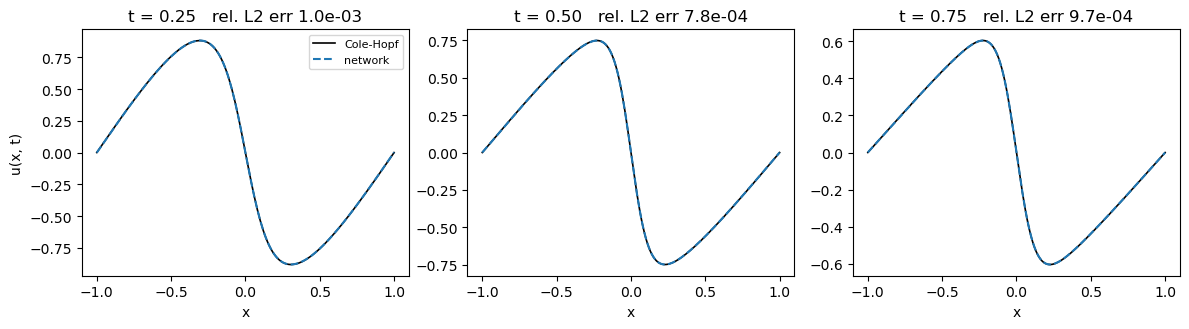

In [5]:
# Against the Cole-Hopf solution
# ------------------------------
xs = np.linspace(-1, 1, 201)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for k, t in enumerate((0.25, 0.5, 0.75)):
    XT = np.column_stack([xs, np.full_like(xs, t)])
    u_ex = burgers_exact(xs, t, nu)
    u_nn = net.predict_batch_np(XT).ravel()
    ax[k].plot(xs, u_ex, "k-", lw=1.2, label="Cole-Hopf")
    ax[k].plot(xs, u_nn, "C0--", label="network")
    ax[k].set_title("t = %.2f   rel. L2 err %.1e" % (t, np.linalg.norm(u_nn - u_ex) / np.linalg.norm(u_ex)))
    ax[k].set_xlabel("x")
    print("t = %.2f: relative L2 error %.2e, max %.2e"
          % (t, np.linalg.norm(u_nn - u_ex) / np.linalg.norm(u_ex), np.abs(u_nn - u_ex).max()))
ax[0].set_ylabel("u(x, t)")
ax[0].legend(fontsize=8)
plt.tight_layout()

max |u_net - u_exact| on the coarse grid: 4.63e-03


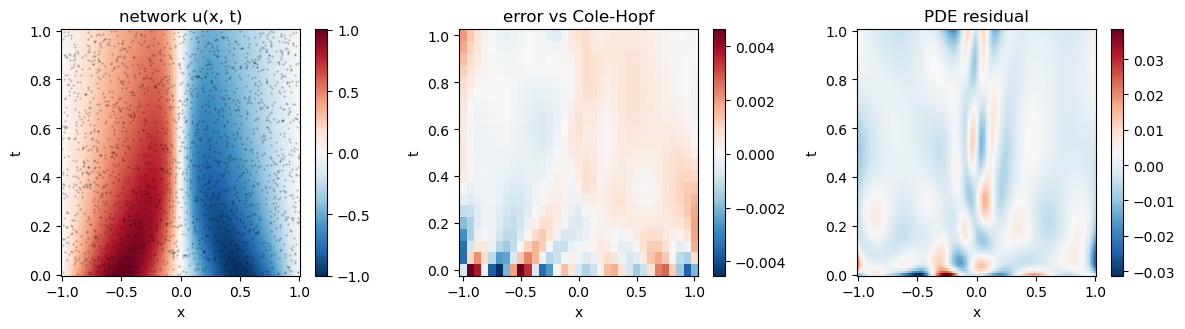

In [6]:
# The whole space-time solution and the residual field:
xg, tg = np.meshgrid(np.linspace(-1, 1, 161), np.linspace(0, 1, 101))
XT = np.column_stack([xg.ravel(), tg.ravel()])
u_nn = net.predict_batch_np(XT).reshape(xg.shape)
u_ex = burgers_exact(xg[::5, ::5], tg[::5, ::5], nu)     # coarser: the quadrature is a Python loop
n_pts = XT.shape[0]
u, u_x, u_xx = net.predict_derivatives_np(XT, np.tile([[1.0, 0.0]], (n_pts, 1)), order=2)
_, u_t, _ = net.predict_derivatives_np(XT, np.tile([[0.0, 1.0]], (n_pts, 1)), order=1)
resid = (u_t + u * u_x - nu * u_xx).reshape(xg.shape)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
im = ax[0].pcolormesh(xg, tg, u_nn, shading="auto", cmap="RdBu_r")
plt.colorbar(im, ax=ax[0]), ax[0].set_title("network u(x, t)")
ax[0].plot(X_f[:, 0], X_f[:, 1], "k.", ms=1, alpha=0.25)
im = ax[1].pcolormesh(xg[::5, ::5], tg[::5, ::5], u_nn[::5, ::5] - u_ex, shading="auto", cmap="RdBu_r")
plt.colorbar(im, ax=ax[1]), ax[1].set_title("error vs Cole-Hopf")
im = ax[2].pcolormesh(xg, tg, resid, shading="auto", cmap="RdBu_r")
plt.colorbar(im, ax=ax[2]), ax[2].set_title("PDE residual")
for a in ax:
    a.set_xlabel("x"), a.set_ylabel("t")
plt.tight_layout()
print("max |u_net - u_exact| on the coarse grid: %.2e" % np.abs(u_nn[::5, ::5] - u_ex).max())
plt.show()